## CNNs, Datasets and DataLoaders

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
def get_train_transform(image_size=512):
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    return train_transform

In [ ]:
def get_test_transform(image_size=512):
    valid_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    return valid_transform


In [ ]:
torchvision.datasets.CIFAR10()??

SyntaxError: invalid syntax (<ipython-input-4-0c4aad0563f0>, line 1)

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:02<00:00, 63.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


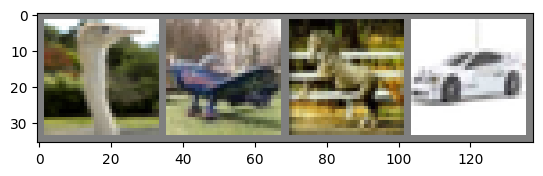

bird  plane horse car  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

$$\mathbb{R}^{BxHxWxC}$$

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # fxhxw
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [ ]:
sum(param.numel() for param in net.parameters())

62006

In [ ]:
net.parameters

<bound method Module.parameters of Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)>

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

num_epochs = 5

In [ ]:
for epoch in range(num_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.211
[1,  4000] loss: 1.906
[1,  6000] loss: 1.669
[1,  8000] loss: 1.569
[1, 10000] loss: 1.500
[1, 12000] loss: 1.434
[2,  2000] loss: 1.382
[2,  4000] loss: 1.367
[2,  6000] loss: 1.352
[2,  8000] loss: 1.306
[2, 10000] loss: 1.307
[2, 12000] loss: 1.301
[3,  2000] loss: 1.214
[3,  4000] loss: 1.217
[3,  6000] loss: 1.208
[3,  8000] loss: 1.203
[3, 10000] loss: 1.192
[3, 12000] loss: 1.190
[4,  2000] loss: 1.100
[4,  4000] loss: 1.112
[4,  6000] loss: 1.111
[4,  8000] loss: 1.112
[4, 10000] loss: 1.121
[4, 12000] loss: 1.119
[5,  2000] loss: 1.045
[5,  4000] loss: 1.035
[5,  6000] loss: 1.033
[5,  8000] loss: 1.046
[5, 10000] loss: 1.061
[5, 12000] loss: 1.033
Finished Training


In [ ]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

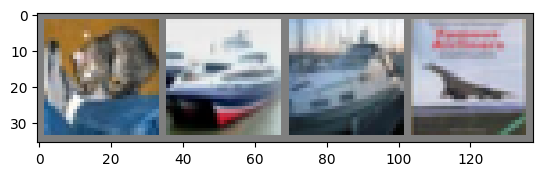

GroundTruth:  cat   ship  ship  plane


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH))
net.eval()

<ipython-input-14-b407d54cfbcd>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(PATH))


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
outputs = net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  frog  ship  ship  plane


In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.inference_mode():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 61 %


In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 64.9 %
Accuracy for class: car   is 66.5 %
Accuracy for class: bird  is 45.0 %
Accuracy for class: cat   is 38.7 %
Accuracy for class: deer  is 54.4 %
Accuracy for class: dog   is 53.3 %
Accuracy for class: frog  is 72.8 %
Accuracy for class: horse is 71.0 %
Accuracy for class: ship  is 79.0 %
Accuracy for class: truck is 69.2 %


In [ ]:
import warnings

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms

warnings.filterwarnings("ignore")

In [ ]:
img = torchvision.io.read_image("astronaut.jpg")

# Using GPU if available
if torch.cuda.is_available():
    img = img.to("cuda")

In [ ]:
img.shape

torch.Size([3, 512, 512])

In [ ]:
def display_img(img: torch.Tensor) -> None:
    plt.imshow(img.permute(1, 2, 0).cpu())

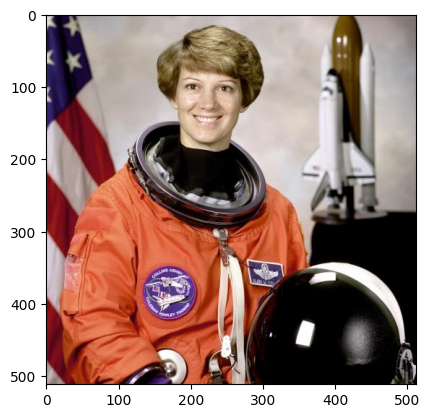

In [ ]:
display_img(img)

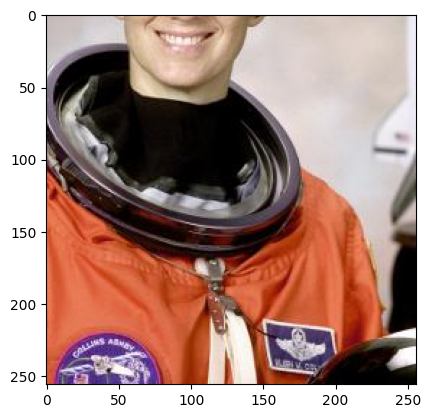

In [ ]:
x = transforms.CenterCrop([256, 256])
display_img(x(img))

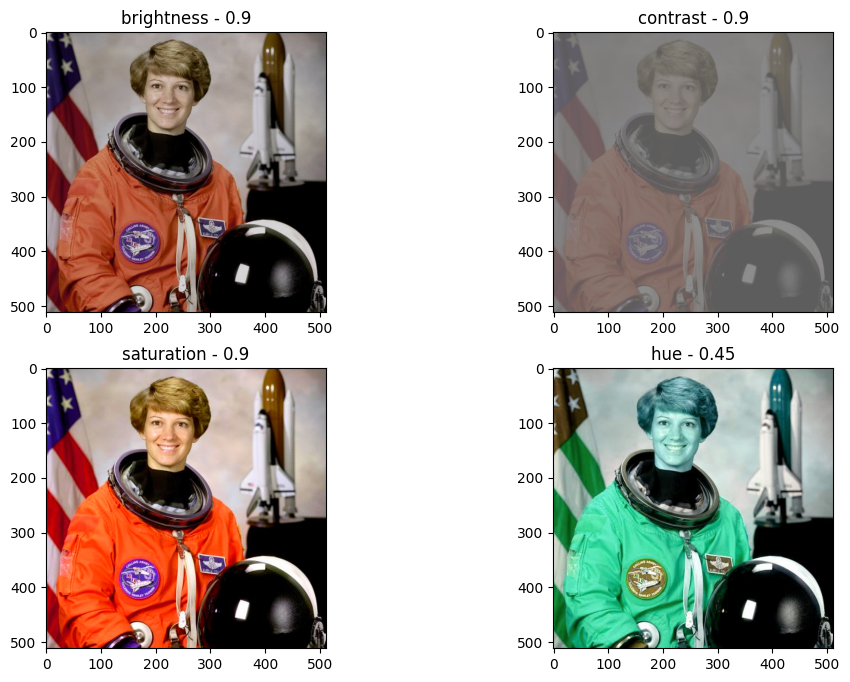

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
NUM = 0.9
x = transforms.ColorJitter(brightness=NUM)
ax[0, 0].imshow(x.forward(img).permute(1, 2, 0).cpu())
ax[0, 0].set_title(f"brightness - {NUM}")
x = transforms.ColorJitter(contrast=NUM)
ax[0, 1].imshow(x.forward(img).permute(1, 2, 0).cpu())
ax[0, 1].set_title(f"contrast - {NUM}")
x = transforms.ColorJitter(saturation=NUM)
ax[1, 0].imshow(x.forward(img).permute(1, 2, 0).cpu())
ax[1, 0].set_title(f"saturation - {NUM}")
x = transforms.ColorJitter(hue=0.45)
ax[1, 1].imshow(x.forward(img).permute(1, 2, 0).cpu())
ax[1, 1].set_title(f"hue - 0.45")
fig.show()

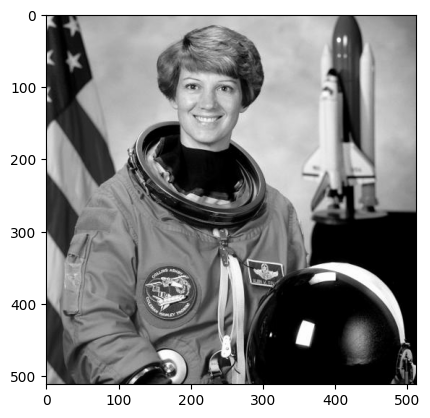

In [ ]:
x = transforms.Grayscale(num_output_channels=3)

display_img(x.forward(img))

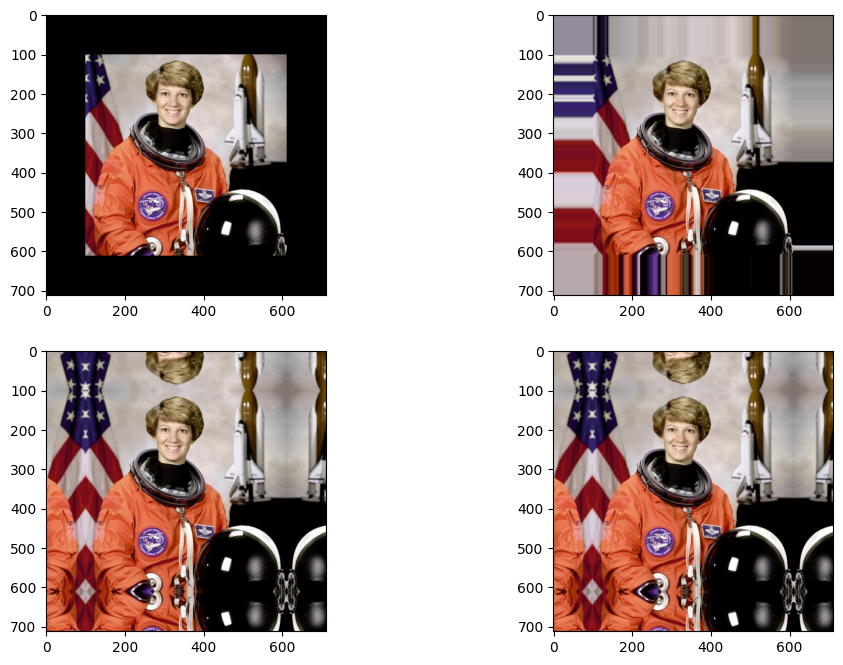

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
NUM = 100
x = transforms.Pad(NUM, padding_mode="constant")
ax[0, 0].imshow(x.forward(img).permute(1, 2, 0).cpu())
x = transforms.Pad(NUM, padding_mode="edge")
ax[0, 1].imshow(x.forward(img).permute(1, 2, 0).cpu())
x = transforms.Pad(NUM, padding_mode="reflect")
ax[1, 0].imshow(x.forward(img).permute(1, 2, 0).cpu())
x = transforms.Pad(NUM, padding_mode="symmetric")
ax[1, 1].imshow(x.forward(img).permute(1, 2, 0).cpu())
fig.show()

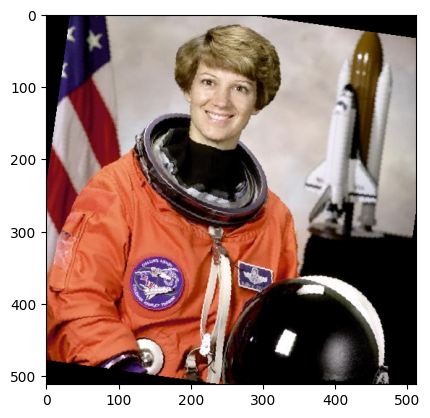

In [ ]:
x = transforms.RandomAffine(30)
display_img(x.forward(img))

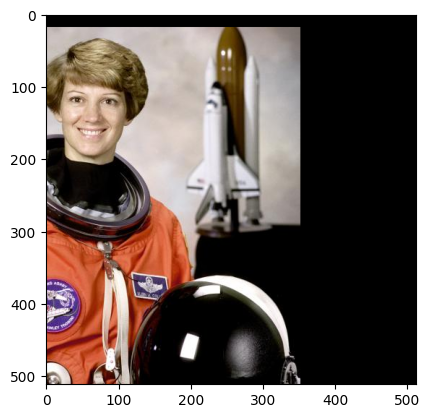

In [ ]:
x = transforms.RandomAffine(0, translate=(0.6, 0.2))
display_img(x.forward(img))


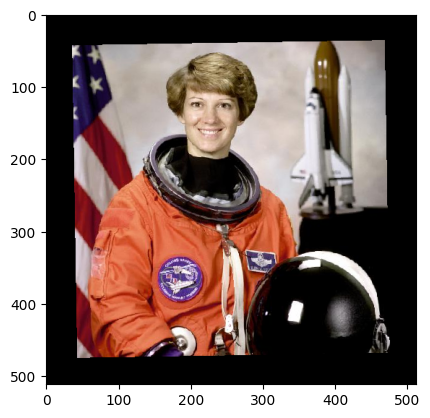

In [ ]:
x = transforms.RandomAffine(20,  scale=(0.5, 5))
display_img(x.forward(img))

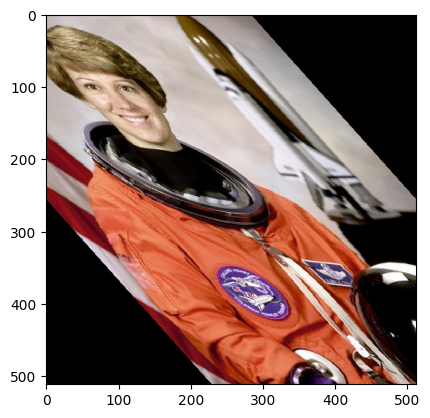

In [ ]:
x = transforms.RandomAffine(0, shear=45)
display_img(x.forward(img))

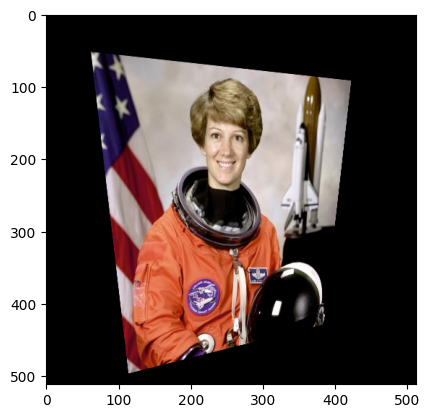

In [ ]:
x = transforms.RandomPerspective(distortion_scale=0.5, p=0.9)
display_img(x.forward(img))

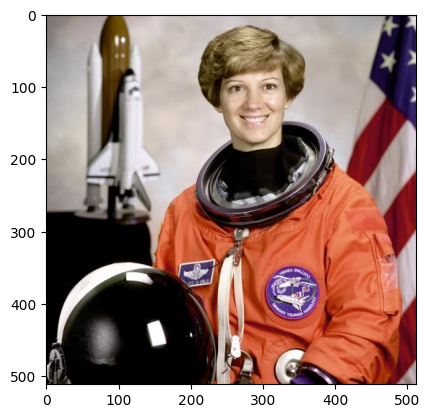

In [ ]:
x = transforms.RandomHorizontalFlip(p=0.5)
display_img(x.forward(img))

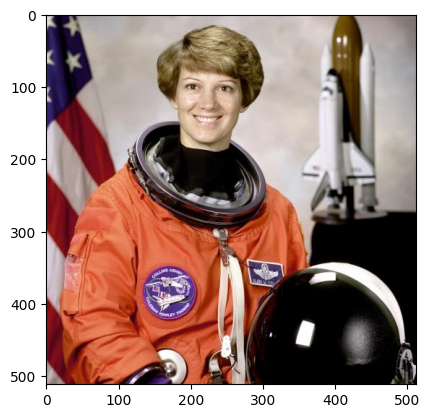

In [ ]:
x = transforms.RandomVerticalFlip(p=0.5)
display_img(x.forward(img))

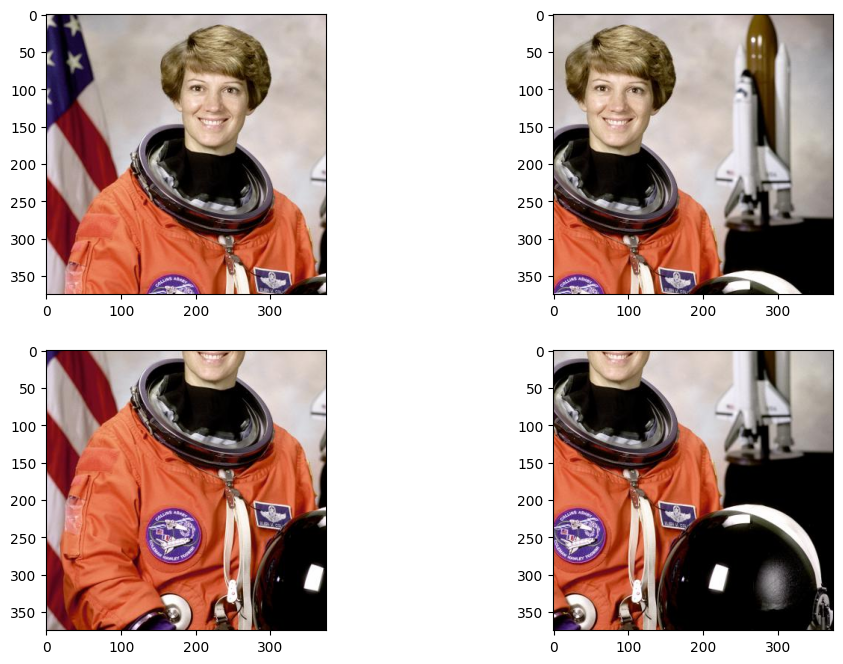

In [ ]:
x = transforms.FiveCrop([375, 375])
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
figs = x.forward(img)
ax[0, 0].imshow(figs[0].permute(1, 2, 0).cpu())
ax[0, 1].imshow(figs[1].permute(1, 2, 0).cpu())
ax[1, 0].imshow(figs[2].permute(1, 2, 0).cpu())
ax[1, 1].imshow(figs[3].permute(1, 2, 0).cpu())
fig.show()

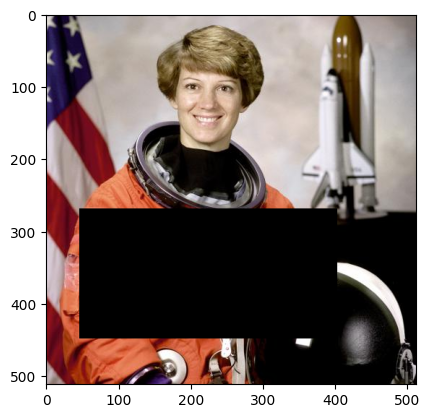

In [ ]:
x = transforms.RandomErasing(p=0.75)
display_img(x.forward(img))